In [2]:
# Import necessary libraries
import pandas as pd
import numpy as np


In [3]:
# Load the dataset
df=pd.read_csv('well.csv')

df.head()

,Depth (ft),Weight on bit (k-lbs),Temperature Out (deg F),Temperature In(deg F),Pit Total (bbls),Pump Pressure (psi),Hook load (k-lbs),Surface Torque (psi),Rotary Speed (rpm),Flow In (gal/min),Flow Out Percentage (%),ROP (ft/hr)
0,85.18,0.0,93.49,90.87,274.83,463.72,31.77,8.93,151.09,1109.58,101.61,56.80
1,86.18,0.0,93.52,90.83,274.83,459.53,31.01,8.93,151.09,1108.36,101.70,61.14
2,87.23,0.0,94.25,90.91,273.80,454.57,31.01,9.01,61.54,1102.87,96.81,18.58
3,88.26,0.0,94.44,91.14,273.79,451.14,31.16,8.97,60.23,1101.04,96.67,38.29
4,89.36,0.0,94.48,91.18,273.80,456.09,31.54,8.97,61.75,1102.46,96.63,394.38


In [4]:
# display column names
df.columns.tolist()

['Depth (ft)',
 'Weight on bit (k-lbs)',
 'Temperature Out (deg F)',
 'Temperature In(deg F)',
 'Pit Total (bbls)',
 'Pump Pressure (psi)',
 'Hook load (k-lbs)',
 'Surface Torque (psi)',
 'Rotary Speed (rpm)',
 'Flow In (gal/min)',
 'Flow Out Percentage (%)',
 'ROP (ft/hr)']

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7305 entries, 0 to 7304
Data columns (total 12 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Depth (ft)               7305 non-null   float64
 1   Weight on bit (k-lbs)    7305 non-null   float64
 2   Temperature Out (deg F)  7305 non-null   float64
 3   Temperature In(deg F)    7305 non-null   float64
 4   Pit Total (bbls)         7305 non-null   float64
 5   Pump Pressure (psi)      7305 non-null   float64
 6   Hook load (k-lbs)        7305 non-null   float64
 7   Surface Torque (psi)     7305 non-null   float64
 8   Rotary Speed (rpm)       7305 non-null   float64
 9   Flow In (gal/min)        7305 non-null   float64
 10  Flow Out Percentage (%)  7305 non-null   float64
 11  ROP (ft/hr)              7305 non-null   float64
dtypes: float64(12)
memory usage: 685.0 KB


In [6]:
# Basic Statistics
df.describe()

,Depth (ft),Weight on bit (k-lbs),Temperature Out (deg F),Temperature In(deg F),Pit Total (bbls),Pump Pressure (psi),Hook load (k-lbs),Surface Torque (psi),Rotary Speed (rpm),Flow In (gal/min),Flow Out Percentage (%),ROP (ft/hr)
count,7305.000000,7305.000000,7305.000000,7305.000000,7305.000000,7305.00000,7305.000000,7305.000000,7305.000000,7305.000000,7305.000000,7305.000000
mean,3837.245322,23.124585,126.067060,118.319247,236.933788,1267.26574,81.302318,131.044163,54.945413,716.206999,79.696278,41.637176
std,2146.875180,9.114158,12.255701,11.932178,18.238543,490.21384,26.507259,48.660962,25.929834,141.464276,11.897750,67.729579
min,85.180000,0.000000,84.070000,85.000000,170.910000,19.94000,27.270000,0.000000,0.000000,0.000000,0.690000,0.710000
25%,1972.930000,18.310000,116.130000,108.870000,224.540000,665.78000,54.720000,117.090000,38.090000,620.260000,72.650000,11.410000
50%,3854.860000,23.830000,124.860000,117.220000,238.110000,1432.67000,80.240000,140.350000,50.380000,700.160000,80.710000,17.990000
75%,5693.100000,29.680000,136.490000,126.860000,249.560000,1669.68000,105.630000,157.280000,75.950000,824.550000,88.840000,44.340000
max,7536.250000,47.050000,151.700000,146.310000,279.880000,2200.43000,148.930000,273.710000,271.580000,3317.510000,111.210000,901.440000


In [7]:
# Data Shape 
df.shape

(7305, 12)

In [8]:
# Finding the Missing Values 
df.isnull().sum()


Depth (ft)                 0
Weight on bit (k-lbs)      0
Temperature Out (deg F)    0
Temperature In(deg F)      0
Pit Total (bbls)           0
Pump Pressure (psi)        0
Hook load (k-lbs)          0
Surface Torque (psi)       0
Rotary Speed (rpm)         0
Flow In (gal/min)          0
Flow Out Percentage (%)    0
ROP (ft/hr)                0
dtype: int64

In [9]:
# Duplicate rows 
df.duplicated().sum()

np.int64(30)

In [10]:
# Droping the duplicates 
df=df.drop_duplicates()
df.shape

(7275, 12)

In [11]:
# Check for Non-Drilling Records dataset contains some non-drilling operations (connections, tripping, circulation, etc.).
cols = [
    'Weight on bit (k-lbs)',
    'Rotary Speed (rpm)',
    'Flow In (gal/min)',
    'ROP (ft/hr)'
]


for col in cols:
    print(f"{col}: {(df[col] == 0).sum()}")

Weight on bit (k-lbs): 196
Rotary Speed (rpm): 375
Flow In (gal/min): 68
ROP (ft/hr): 0


In [12]:
df = df[
    (df['Weight on bit (k-lbs)'] > 0) &
    (df['Rotary Speed (rpm)'] > 0) &
    (df['Flow In (gal/min)'] > 0) &
    (df['ROP (ft/hr)'] > 0)
]

print(df.shape)

(6727, 12)


In [13]:
# keep only active drilling data.
df = df[
    (df['Weight on bit (k-lbs)'] > 0) &
    (df['Rotary Speed (rpm)'] > 0) &
    (df['Flow In (gal/min)'] > 0) &
    (df['ROP (ft/hr)'] > 0)
]

print(df.shape)

(6727, 12)


In [14]:
corr = df.corr(numeric_only=True)

print(
    corr['ROP (ft/hr)']
    .sort_values(ascending=False)
)

ROP (ft/hr)                1.000000
Flow In (gal/min)          0.568232
Rotary Speed (rpm)         0.538460
Pit Total (bbls)           0.438072
Temperature In(deg F)     -0.105418
Surface Torque (psi)      -0.343359
Flow Out Percentage (%)   -0.360581
Temperature Out (deg F)   -0.378144
Hook load (k-lbs)         -0.567988
Weight on bit (k-lbs)     -0.584218
Pump Pressure (psi)       -0.615350
Depth (ft)                -0.645190
Name: ROP (ft/hr), dtype: float64


In [15]:
corr = df.corr(numeric_only=True)

print(corr['ROP (ft/hr)'].sort_values(ascending=False))

ROP (ft/hr)                1.000000
Flow In (gal/min)          0.568232
Rotary Speed (rpm)         0.538460
Pit Total (bbls)           0.438072
Temperature In(deg F)     -0.105418
Surface Torque (psi)      -0.343359
Flow Out Percentage (%)   -0.360581
Temperature Out (deg F)   -0.378144
Hook load (k-lbs)         -0.567988
Weight on bit (k-lbs)     -0.584218
Pump Pressure (psi)       -0.615350
Depth (ft)                -0.645190
Name: ROP (ft/hr), dtype: float64


In [ ]:
import seaborn as sns

# Heat map - Shows the correlation between the features and the target variable 
import matplotlib.pyplot as plt
plt.figure(figsize=(12,10))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')

NameError: name 'sns' is not defined

<Figure size 1200x1000 with 0 Axes>

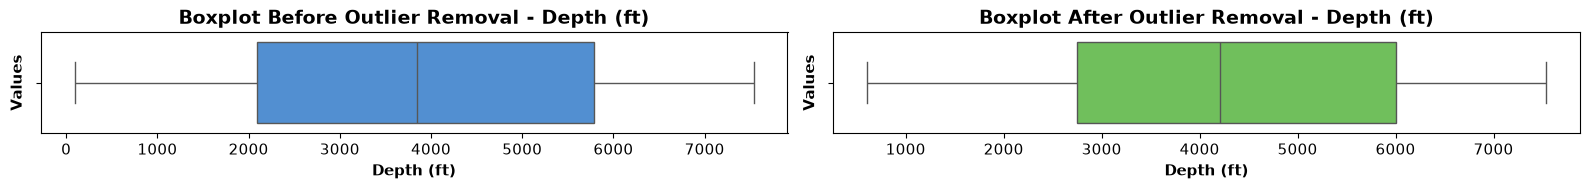

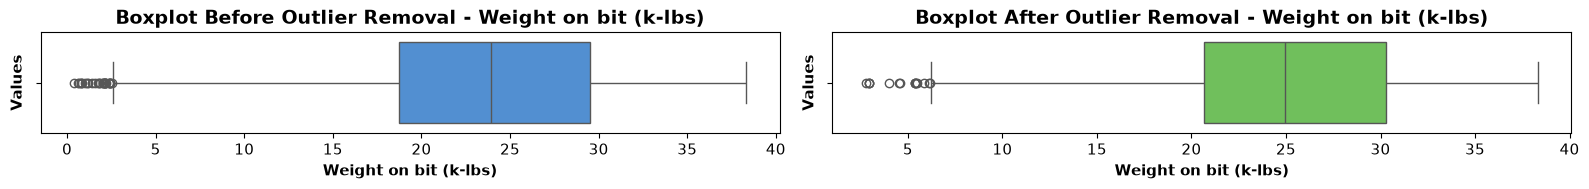

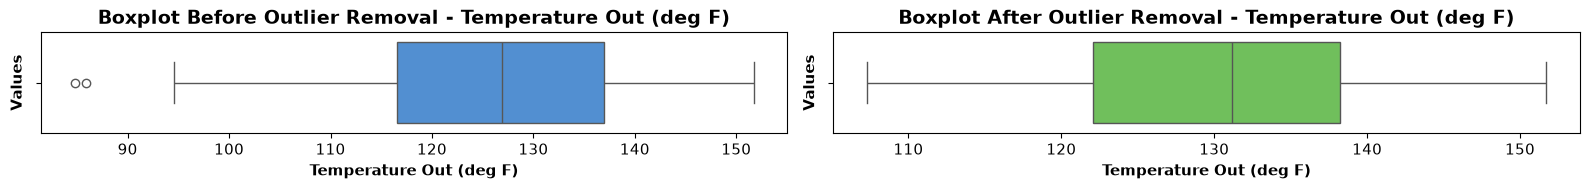

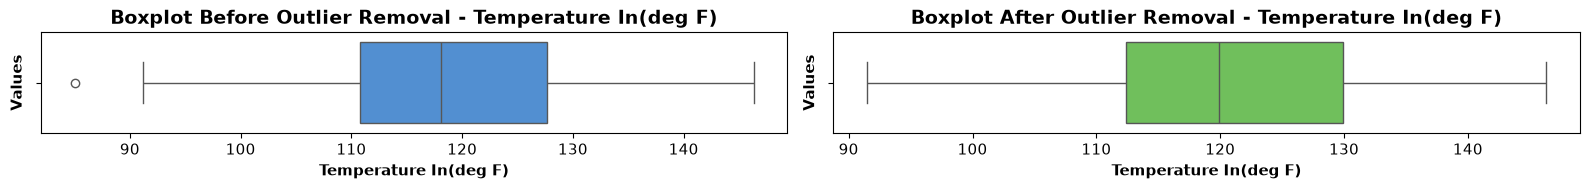

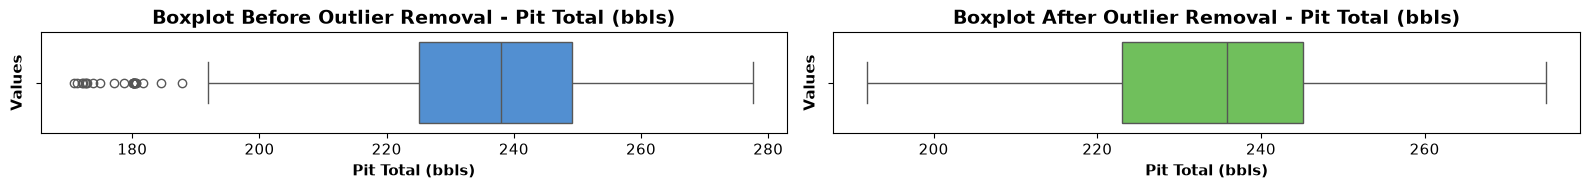

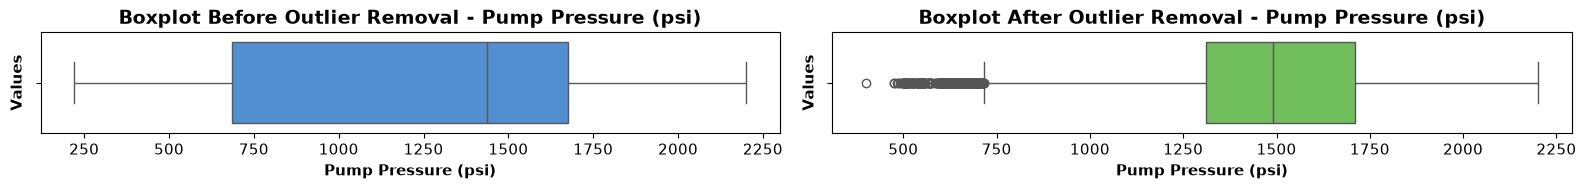

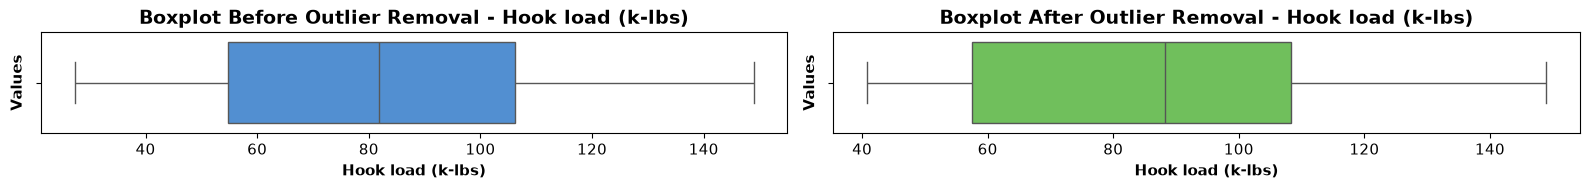

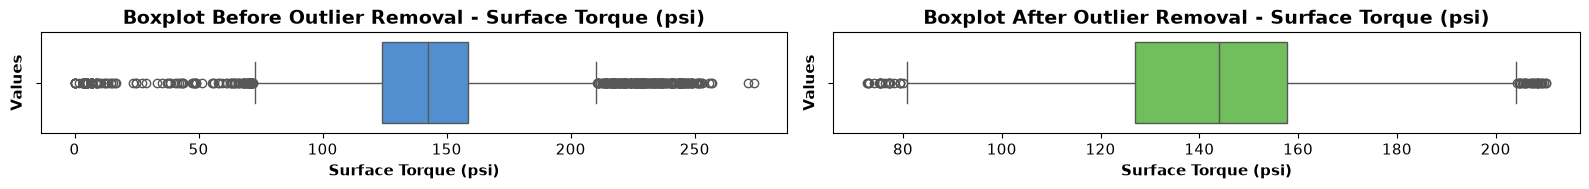

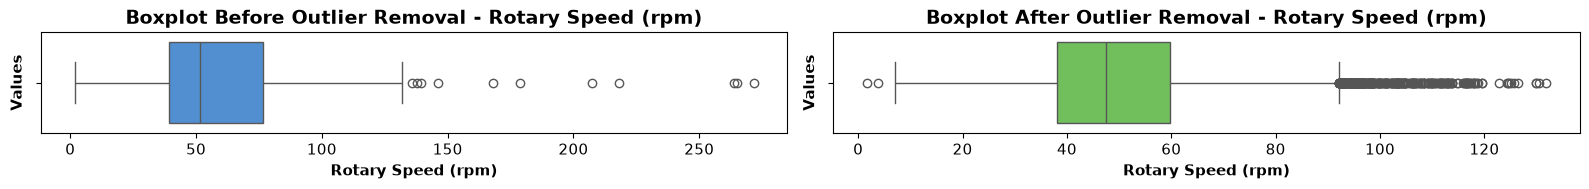

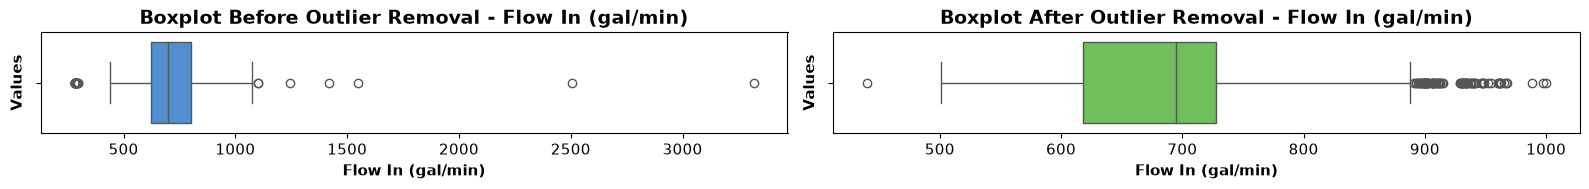

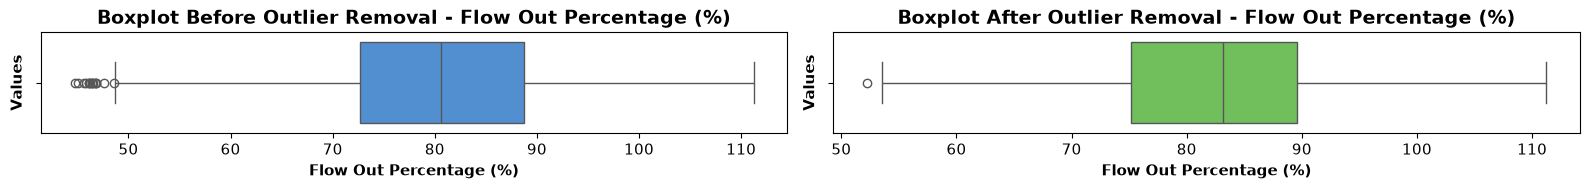

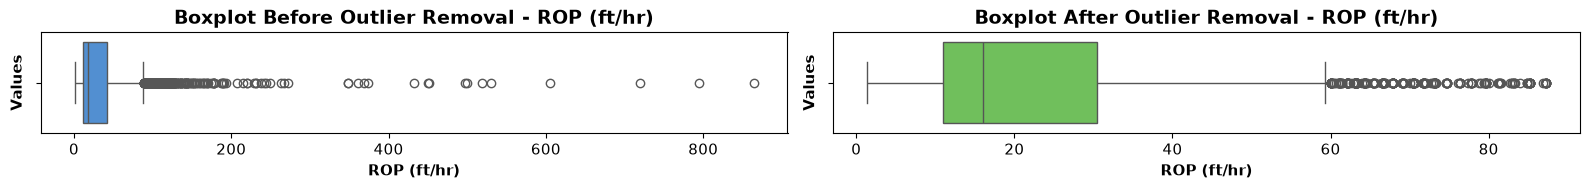

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Features and also for target variable
features = df.columns

def remove_outliers(df, features):
    # Calculation of the Interquartile Range (IQR) for each feature
    Q1 = df[features].quantile(0.25)
    Q3 = df[features].quantile(0.75)
    IQR = Q3 - Q1
    
    # Calculation of the lower and upper bounds for outlier detection
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    # Row-wise filtering: Keep rows where ALL features fall within the valid range
    non_outlier_mask = ((df[features] >= lower_bound) & (df[features] <= upper_bound)).all(axis=1)
    
    return df[non_outlier_mask].copy()

# Assign the result of the function to data_no_outliers
data_no_outliers = remove_outliers(df, features)

# Saving the data without outliers to a new CSV file
data_no_outliers.to_csv('data_no_outliers.csv', index=False) 

# Visualize boxplots side-by-side (1 row, 2 columns per feature)
for feature in features:
    # Set a clean canvas size (16 inches wide, 4 inches tall)
    fig, axes = plt.subplots(1, 2, figsize=(16, 2))
    
    # 1. Left Plot: Before Outlier Removal
    sns.boxplot(x=df[feature], ax=axes[0], color="#3d8ee6")
    axes[0].set_title(f'Boxplot Before Outlier Removal - {feature}', fontsize=14, weight='bold')
    axes[0].set_xlabel(feature, fontsize=11, weight='bold')
    axes[0].set_ylabel('Values', fontsize=11, weight='bold')
    axes[0].tick_params(labelsize=11)

    # 2. Right Plot: After Outlier Removal
    sns.boxplot(x=data_no_outliers[feature], ax=axes[1], color="#66cf4c")
    axes[1].set_title(f'Boxplot After Outlier Removal - {feature}', fontsize=14, weight='bold')
    axes[1].set_xlabel(feature, fontsize=11, weight='bold')
    axes[1].set_ylabel('Values', fontsize=11, weight='bold')
    axes[1].tick_params(labelsize=11)

    # Ensures proper layout spacing and displays the paired row
    plt.tight_layout()
    plt.show()

In [ ]:
df=pd.read_csv('data_no_outliers.csv')
features = [
    'Depth (ft)',
    'Weight on bit (k-lbs)',
    'Temperature Out (deg F)',
    'Temperature In(deg F)',
    'Pit Total (bbls)',
    'Pump Pressure (psi)',
    'Hook load (k-lbs)',
    'Surface Torque (psi)',
    'Rotary Speed (rpm)',
    'Flow In (gal/min)',
    'Flow Out Percentage (%)'
]

target = 'ROP (ft/hr)'

In [ ]:
# Target and independent variables 

X = df[features]
y = df[target]

In [ ]:
# Train-Test Split
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [ ]:
# Standardization (Mandatory for SVM)
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

In [ ]:
# Train First SVR Model
from sklearn.svm import SVR

svr = SVR(
    kernel='rbf',
    C=100,
    gamma='scale',
    epsilon=0.1
)

svr.fit(X_train_scaled, y_train)

,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive.The penalty is a squared l2. For an intuitive visualization of theeffects of scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",100
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm.If none is given, 'rbf' will be used. If a callable is given it isused to precompute the kernel matrix.For an intuitive visualization of different kernel typessee :ref:`sphx_glr_auto_examples_svm_plot_svm_regression.py`",'rbf'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"epsilon epsilon: float, default=0.1Epsilon in the epsilon-SVR model. It specifies the epsilon-tubewithin which no penalty is associated in the training loss functionwith points predicted within a distance epsilon from the actualvalue. Must be non-negative.",0.1
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide <shrinking_svm>`.",True
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False
,"max_iter max_iter: int, default=-1Hard limit on iterations within solver, or -1 for no limit.",-1


In [ ]:
# Prediction
y_pred = svr.predict(X_test_scaled)

In [ ]:
# Evaluation
from sklearn.metrics import r2_score
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
import numpy as np

r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print("R² =", r2)
print("MAE =", mae)
print("RMSE =", rmse)

R² = 0.8124733277999265
MAE = 4.449759115752724
RMSE = 7.404447624217855


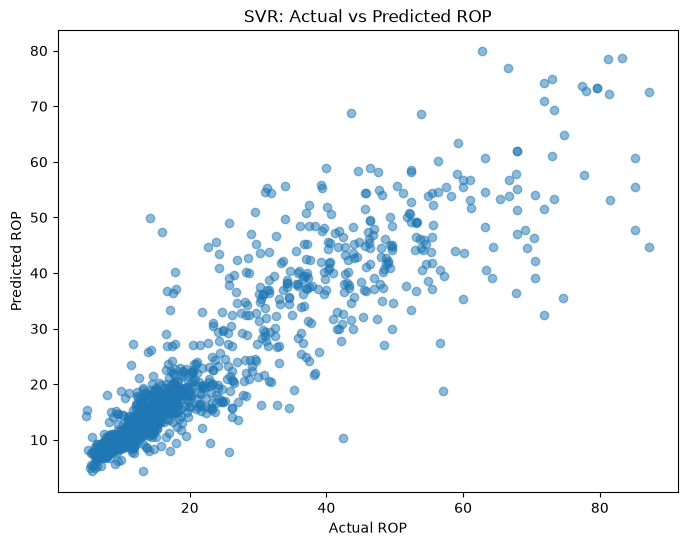

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

plt.scatter(y_test, y_pred, alpha=0.5)

plt.xlabel("Actual ROP")
plt.ylabel("Predicted ROP")
plt.title("SVR: Actual vs Predicted ROP")

plt.show()

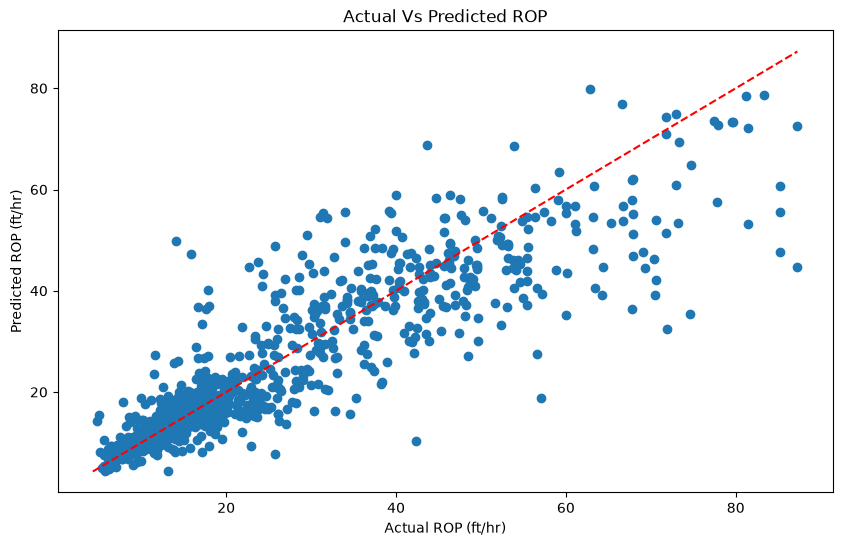

In [ ]:
plt.figure(figsize=(10,6))
plt.scatter(y_test, y_pred)
plt.xlabel('Actual ROP (ft/hr)')
plt.ylabel('Predicted ROP (ft/hr)')
plt.title('Actual Vs Predicted ROP')

min_val = min(min(y_test), min(y_pred))
max_val = max(max(y_test), max(y_pred))

plt.plot([min_val, max_val], [min_val, max_val], 'r--',label ="Actual ROP = Predicted ROP ")  # Diagonal line


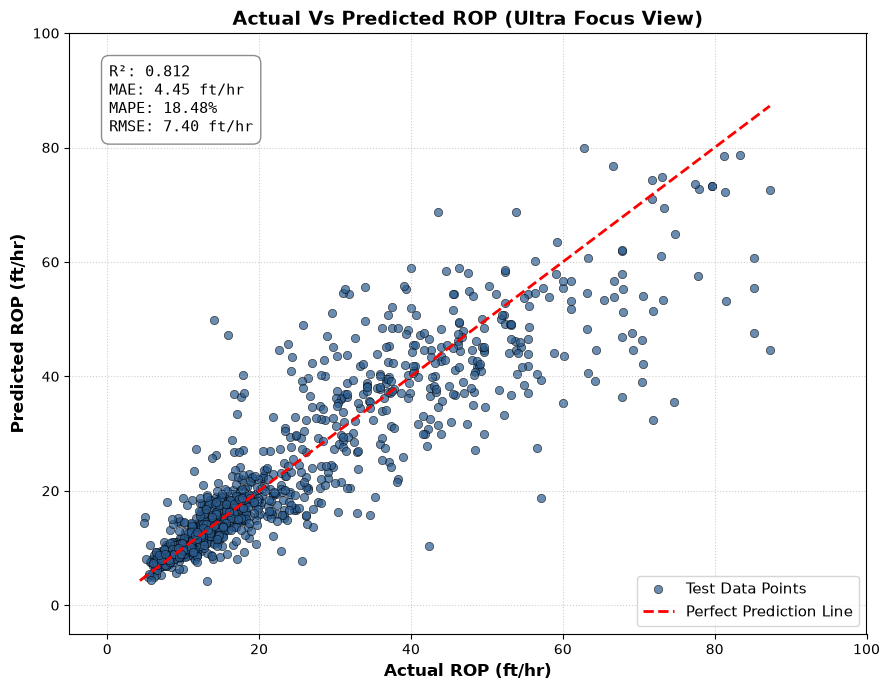

In [ ]:
import numpy as np
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

# 1. Calculate evaluation metrics
r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mape = np.mean(np.abs((y_test - y_pred) / (y_test + 1e-10))) * 100

# 2. Plot setup
plt.figure(figsize=(9, 7))  # Made slightly more square for a balanced zoom view
plt.scatter(y_test, y_pred, alpha=0.7, color='#2b5c8f', edgecolors='k', linewidth=0.5, label="Test Data Points")

plt.xlabel('Actual ROP (ft/hr)', fontsize=12, weight='bold')
plt.ylabel('Predicted ROP (ft/hr)', fontsize=12, weight='bold')
plt.title('Actual Vs Predicted ROP (Ultra Focus View)', fontsize=14, weight='bold')

# 3. Diagonal reference line
min_val = min(min(y_test), min(y_pred))
max_val = max(max(y_test), max(y_pred))
plt.plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=2, label="Perfect Prediction Line") 

# ==========================================
# ULTRA FOCUS AREA LIMITS (Zoomed into 0-150)
# ==========================================
plt.xlim(-5, 100)
plt.ylim(-5, 100)

# Add grid lines to make tracking individual points easier in tight space
plt.grid(True, linestyle=':', alpha=0.6)

# 4. Create string text for metrics box
metrics_box = (
    f"R²: {r2:.3f}\n"
    f"MAE: {mae:.2f} ft/hr\n"
    f"MAPE: {mape:.2f}%\n"
    f"RMSE: {rmse:.2f} ft/hr"
)

# Position changed to 'upper left' but adjusted nicely for the tight window
box_properties = dict(boxstyle='round,pad=0.5', facecolor='white', alpha=0.9, edgecolor='gray')
plt.text(0.05, 0.95, metrics_box, transform=plt.gca().transAxes, fontsize=11,
         verticalalignment='top', bbox=box_properties, fontfamily='monospace')

# 5. Display indicators
plt.legend(loc='lower right', fontsize=11)

plt.tight_layout()
plt.show()

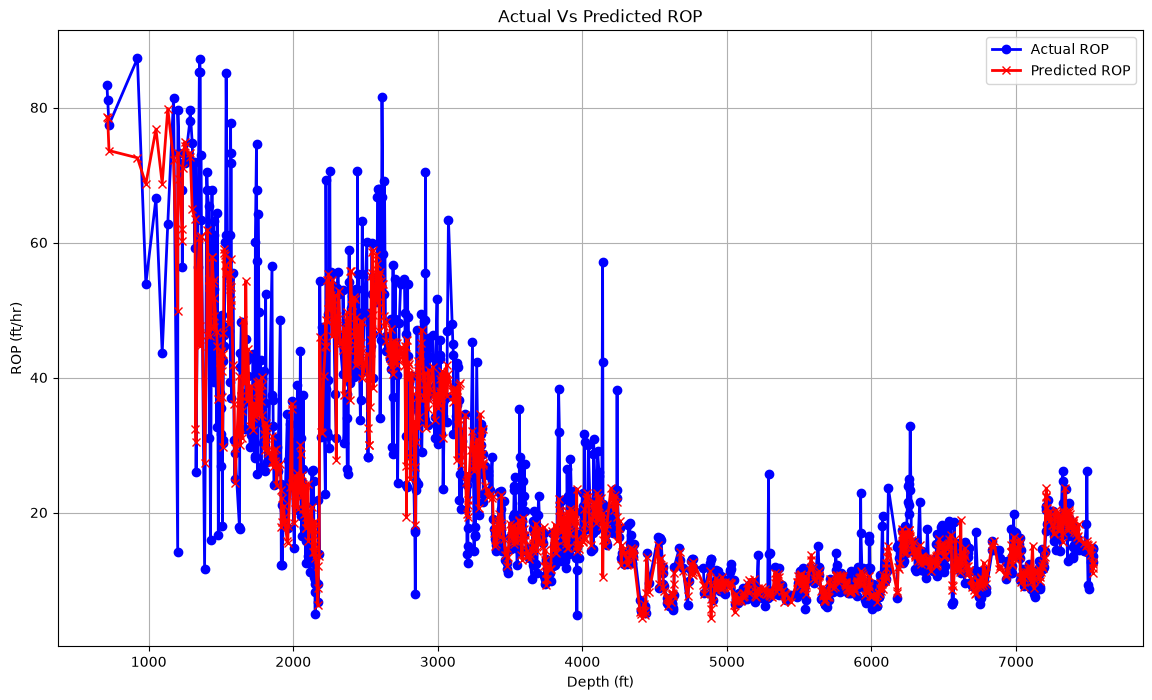

In [ ]:
# Creating a results dataframe to compare actual and predicted values
results = X_test.copy()
results['Actual_ROP'] = y_test
results['Predicted_ROP'] = y_pred

# Sort by depth to see how the model performs at different depths
results = results.sort_values('Depth (ft)')

plt.figure(figsize=(14, 8))

plt.plot(results['Depth (ft)'], results['Actual_ROP'], label='Actual ROP', color='blue', marker='o', linewidth=2)
plt.plot(results['Depth (ft)'], results['Predicted_ROP'], label='Predicted ROP', color='red', marker='x', linewidth=2)
plt.xlabel('Depth (ft)')
plt.ylabel('ROP (ft/hr)')
plt.title('Actual Vs Predicted ROP')
plt.legend()
plt.grid(True)
plt.show()

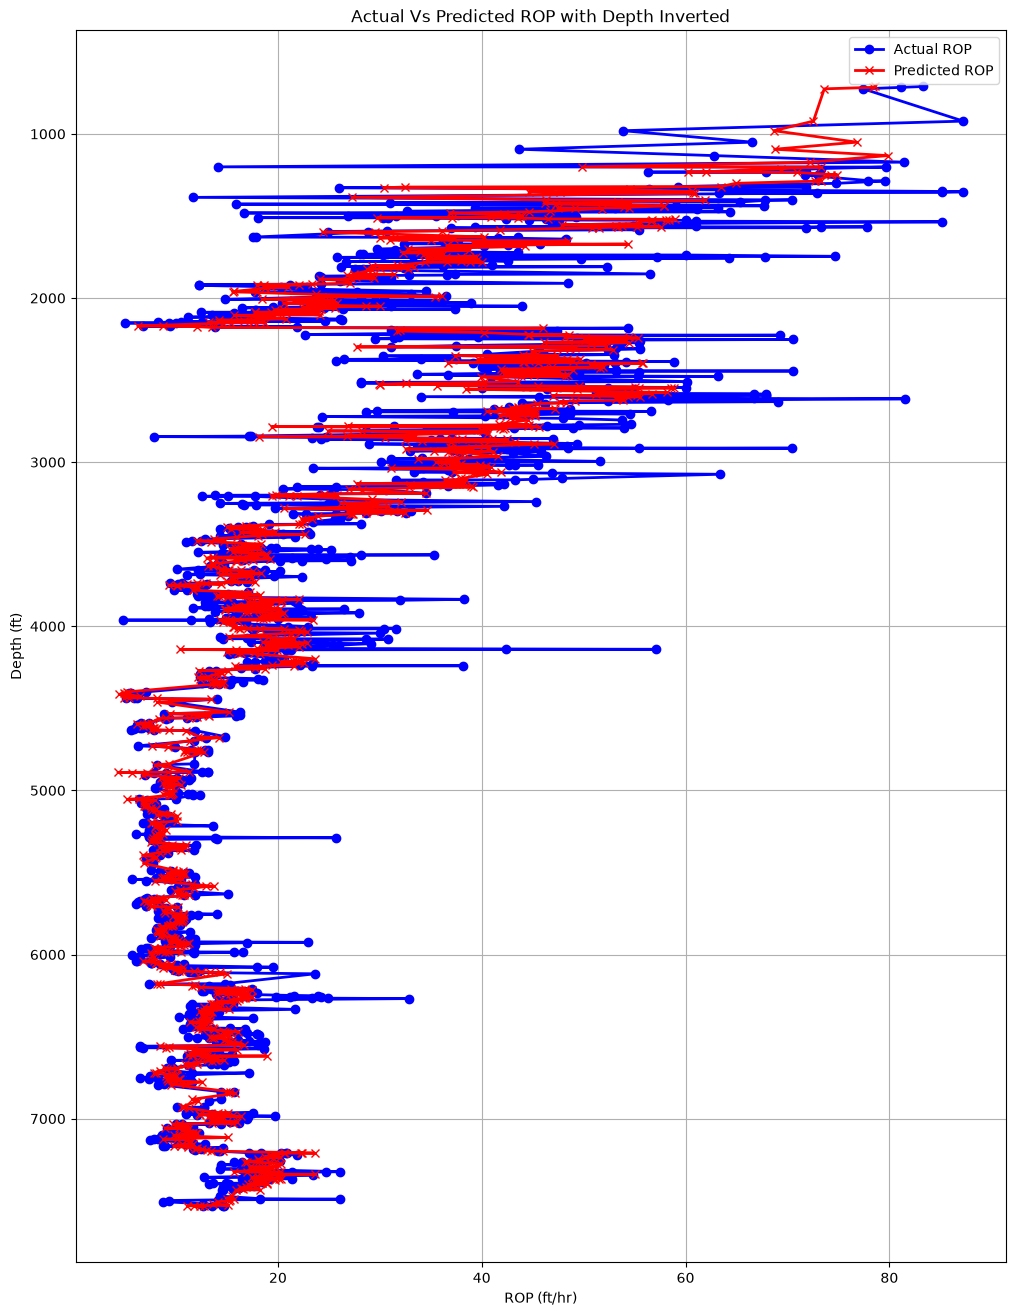

In [ ]:
plt.figure(figsize=(12,16)) 
plt.plot(results['Actual_ROP'],results['Depth (ft)'], label='Actual ROP', color='blue', marker='o', linewidth=2)
plt.plot(results['Predicted_ROP'],results['Depth (ft)'], label='Predicted ROP', color='red', marker='x', linewidth=2)
plt.gca().invert_yaxis()  # Invert y-axis to have depth increasing downwards
plt.ylabel("Depth (ft)")
plt.xlabel('ROP (ft/hr)')
plt.title('Actual Vs Predicted ROP with Depth Inverted')
plt.legend()
plt.grid(True)

plt.show()

In [ ]:

# Hyperparameter Optimization
from sklearn.model_selection import GridSearchCV
from sklearn.svm import SVR

param_grid = {
    'C': [10, 50, 100, 500, 1000],
    'gamma': [0.001, 0.01, 0.1, 'scale'],
    'epsilon': [0.01, 0.05, 0.1, 0.5]
}

grid = GridSearchCV(
    SVR(kernel='rbf'),
    param_grid,
    cv=5,
    scoring='r2',
    n_jobs=-1,
    verbose=2
)

grid.fit(X_train_scaled, y_train)

print("Best Parameters:")
print(grid.best_params_)

print("Best CV Score:")
print(grid.best_score_)

Fitting 5 folds for each of 80 candidates, totalling 400 fits
Best Parameters:
{'C': 100, 'epsilon': 0.5, 'gamma': 0.1}
Best CV Score:
0.8045554912901729
